In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Delivery = pd.read_csv(r"C:\Users\solan\OneDrive\Desktop\Moke_Exam\Data\delivery.csv")
Route = pd.read_csv(r"C:\Users\solan\OneDrive\Desktop\Moke_Exam\Data\Route.csv")

In [3]:
Delivery.head()

,record_id,month,route_id,hub,promised_days,actual_days
0,1,Jan,R1,Mumbai,2,2
1,2,Jan,R2,Chennai,3,4
2,3,Jan,R3,Delhi,5,8
3,4,Jan,R4,Mumbai,6,10
4,5,Feb,R1,Chennai,2,5


In [5]:
Route.head()

,route_id,route,service_type
0,R1,Metro Link,Express
1,R2,City Dash,Express
2,R3,Highway Freight,Standard
3,R4,Rural Feeder,Standard


In [6]:
Delivery.shape

(13, 6)

In [7]:
Route.shape

(4, 3)

In [8]:
Delivery.info()

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   record_id      13 non-null     int64
 1   month          13 non-null     str  
 2   route_id       13 non-null     str  
 3   hub            13 non-null     str  
 4   promised_days  13 non-null     int64
 5   actual_days    13 non-null     int64
dtypes: int64(3), str(3)
memory usage: 899.0 bytes


In [9]:
Route.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   route_id      4 non-null      str  
 1   route         4 non-null      str  
 2   service_type  4 non-null      str  
dtypes: str(3)
memory usage: 312.0 bytes


In [10]:
Delivery.duplicated().sum()

np.int64(1)

In [11]:
Route.duplicated().sum()

np.int64(0)

In [14]:
Delivery = Delivery.drop_duplicates()

In [15]:
Delivery.shape

(12, 6)

In [21]:
data = Delivery.merge(Route, how='left', on='route_id')

In [24]:
data.head()

,record_id,month,route_id,hub,promised_days,actual_days,route,service_type
0,1,Jan,R1,Mumbai,2,2,Metro Link,Express
1,2,Jan,R2,Chennai,3,4,City Dash,Express
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard
4,5,Feb,R1,Chennai,2,5,Metro Link,Express


In [27]:
data = data.assign(Delay_days=data['actual_days'] - data['promised_days'])

In [28]:
data.head()

,record_id,month,route_id,hub,promised_days,actual_days,route,service_type,Delay_days
0,1,Jan,R1,Mumbai,2,2,Metro Link,Express,0
1,2,Jan,R2,Chennai,3,4,City Dash,Express,1
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard,3
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard,4
4,5,Feb,R1,Chennai,2,5,Metro Link,Express,3


Text(0.5, 1.0, 'Delay Days by Month')

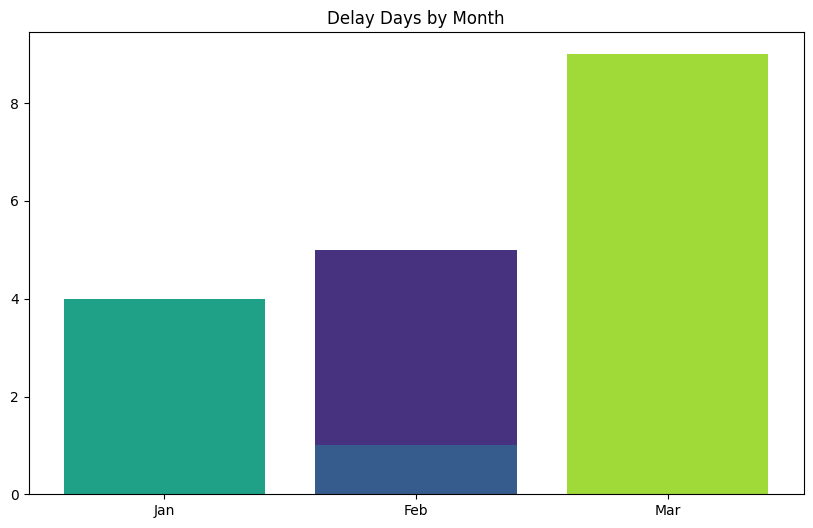

In [34]:
plt.figure(figsize=(10, 6))
plt.bar(data['month'], data['Delay_days'], color=sns.color_palette("viridis"))
plt.title('Delay Days by Month')